# Model Setup  

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
API_key = os.getenv("GOOGLE_API_KEY")

In [3]:
os.environ["LANGCHAIN_PROJECT"] = "Research Assistant"

In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI
model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash", 
    google_api_key=API_key,
    temperature=0,
)

# Goal

Our goal is to build a lightweight, multi-agent system around chat models that customizes the research process.

- Source Selection
- Planning
- LLM Utilization
- Research Process
- Output Format

# Generate Analysts: Human-In-The-Loop
- Create analysts and review them using human-in-the-loop.

## state

In [5]:
from typing import List
from typing_extensions import TypedDict
from pydantic import BaseModel, Field

In [6]:
class Analyst(BaseModel):
    affiliation: str = Field(
        description="Primary affiliation of the analyst.",
    )
    name: str = Field(
        description="Name of the analyst."
    )
    role: str = Field(
        description="Role of the analyst in the context of the topic.",
    )
    description: str = Field(
        description="Description of the analyst focus, concerns, and motives.",
    )
    @property
    def persona(self) -> str:
        return f"Name: {self.name}\nRole: {self.role}\nAffiliation: {self.affiliation}\nDescription: {self.description}\n"

In [7]:
class Perspectives(BaseModel):
    analysts: List[Analyst] = Field(
        description="Comprehensive list of analysts with their roles and affiliations.",
    )

In [8]:
class GenerateAnalystsState(TypedDict):
    topic: str # Research topic
    max_analysts: int # Number of analysts
    human_analyst_feedback: str # Human feedback
    analysts: List[Analyst] # Analyst asking questions

In [9]:
from IPython.display import Image, display
from langgraph.graph import START, END, StateGraph
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

In [10]:
analyst_instructions="""You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:

1. First, review the research topic:
{topic}
        
2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: 
        
{human_analyst_feedback}
    
3. Determine the most interesting themes based upon documents and / or feedback above.
                    
4. Pick the top {max_analysts} themes.

5. Assign one analyst to each theme."""

In [11]:
def create_analysts(state: GenerateAnalystsState):
    
    """ Create analysts """
    
    topic=state['topic']
    max_analysts=state['max_analysts']
    human_analyst_feedback=state.get('human_analyst_feedback', '')
        
    # Enforce structured output
    structured_llm = model.with_structured_output(Perspectives)

    # System message
    system_message = analyst_instructions.format(topic=topic,
                                                            human_analyst_feedback=human_analyst_feedback, 
                                                            max_analysts=max_analysts)

    # Generate question 
    analysts = structured_llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content="Generate the set of analysts.")])
    
    # Write the list of analysis to state
    return {"analysts": analysts.analysts}

In [12]:
def human_feedback(state: GenerateAnalystsState):
    """ No-op node that should be interrupted on """
    pass

In [13]:
def should_continue(state: GenerateAnalystsState):
    """ Return the next node to execute """

    # Check if human feedback
    human_analyst_feedback=state.get('human_analyst_feedback', None)
    if human_analyst_feedback:
        return "create_analysts"
    
    # Otherwise end
    return END

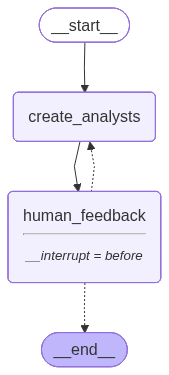

In [14]:
# Graph builder 
builder = StateGraph(GenerateAnalystsState)
# nodes 
builder.add_node("create_analysts", create_analysts)
builder.add_node("human_feedback", human_feedback)
# edegs 
builder.add_edge(START, "create_analysts")
builder.add_edge("create_analysts", "human_feedback")
builder.add_conditional_edges("human_feedback", should_continue, ["create_analysts", END])

# Compile
memory = MemorySaver()
graph = builder.compile(interrupt_before=['human_feedback'], checkpointer=memory)

# View
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

## test 

In [15]:
# Input
max_analysts = 3 
topic = "AI in healthcare"
thread = {"configurable": {"thread_id": "1"}}

In [16]:
# Run the graph until the first interruption
for event in graph.stream({"topic":topic,"max_analysts":max_analysts,}, thread, stream_mode="values"):
    # Review
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50)  

Name: Dr. Anya Sharma
Affiliation: Global Health Innovations Institute
Role: Lead Medical AI Strategist
Description: Focuses on the transformative potential of AI in improving diagnostic precision, enabling earlier disease detection, and tailoring treatment plans for individual patients. Concerned with clinical validation, integration into existing workflows, and demonstrating tangible patient outcomes.
--------------------------------------------------
Name: Mr. Ethan Vance
Affiliation: Digital Rights & Healthcare Advocacy Group
Role: Senior AI Ethics Researcher
Description: Investigates the ethical implications of AI in healthcare, particularly concerning algorithmic bias, data privacy, and equitable access. Advocates for robust regulatory frameworks, transparency in AI models, and patient consent, ensuring AI benefits all populations without exacerbating health disparities.
--------------------------------------------------
Name: Ms. Olivia Chen
Affiliation: Healthcare Systems Optim

In [17]:
# Get state and look at next node
state = graph.get_state(thread)
state.next

Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]


('human_feedback',)

In [18]:
graph.update_state(thread, {"human_analyst_feedback": 
                            "add some company in the file"}, as_node="human_feedback")

Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]


{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f134b88-51db-6a72-8002-7f715903dd15'}}

In [19]:
# Continue the graph execution
for event in graph.stream(None, thread, stream_mode="values"):
    # Review
    analysts = event.get('analysts', '')
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Affiliation: {analyst.affiliation}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.description}")
            print("-" * 50) 

Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]


Name: Dr. Anya Sharma
Affiliation: Global Health Innovations Institute
Role: Lead Medical AI Strategist
Description: Focuses on the transformative potential of AI in improving diagnostic precision, enabling earlier disease detection, and tailoring treatment plans for individual patients. Concerned with clinical validation, integration into existing workflows, and demonstrating tangible patient outcomes.
--------------------------------------------------
Name: Mr. Ethan Vance
Affiliation: Digital Rights & Healthcare Advocacy Group
Role: Senior AI Ethics Researcher
Description: Investigates the ethical implications of AI in healthcare, particularly concerning algorithmic bias, data privacy, and equitable access. Advocates for robust regulatory frameworks, transparency in AI models, and patient consent, ensuring AI benefits all populations without exacerbating health disparities.
--------------------------------------------------
Name: Ms. Olivia Chen
Affiliation: Healthcare Systems Optim

In [20]:
# If we are satisfied, then we simply supply no feedback
further_feedack = None
graph.update_state(thread, {"human_analyst_feedback": 
                            further_feedack}, as_node="human_feedback")

Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]


{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f134b88-8131-64ec-8004-1c18452baf04'}}

In [21]:
# Continue the graph execution to end
for event in graph.stream(None, thread, stream_mode="updates"):
    print("--Node--")
    node_name = next(iter(event.keys()))
    print(node_name)

Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]


In [22]:
final_state = graph.get_state(thread)
analysts = final_state.values.get('analysts')

Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]
Deserializing unregistered type __main__.Analyst from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'Analyst')]


In [23]:
final_state.next

()

In [24]:
for analyst in analysts:
    print(f"Name: {analyst.name}")
    print(f"Affiliation: {analyst.affiliation}")
    print(f"Role: {analyst.role}")
    print(f"Description: {analyst.description}")
    print("-" * 50) 

Name: Dr. Anya Sharma
Affiliation: Pfizer AI Labs
Role: Lead AI Strategist, Pharmaceutical R&D
Description: Focuses on leveraging AI to accelerate drug discovery, optimize clinical trials, and develop novel therapeutics. Concerned with the efficiency, cost-effectiveness, and market impact of AI-driven pharmaceutical innovation.
--------------------------------------------------
Name: Dr. Ben Carter
Affiliation: Siemens Healthineers AI Division
Role: Director of Clinical AI Solutions
Description: Specializes in the application of AI for enhanced diagnostic imaging, predictive analytics for disease progression, and personalized treatment plans. Prioritizes patient safety, clinical efficacy, and seamless integration into healthcare workflows.
--------------------------------------------------
Name: Ms. Clara Rodriguez
Affiliation: Health Data Governance Institute
Role: Senior Policy Analyst, AI Ethics in Healthcare
Description: Examines the ethical implications of AI in healthcare, focusi

# Conduct Interview

## Generate Question
- The analyst will ask questions to the expert.

In [25]:
import operator
from typing import  Annotated
from langgraph.graph import MessagesState

In [26]:
class InterviewState(MessagesState):
    max_num_turns: int # Number turns of conversation
    context: Annotated[list, operator.add] # Source docs
    analyst: Analyst # Analyst asking questions
    interview: str # Interview transcript
    sections: list # Final key we duplicate in outer state for Send() API


In [27]:
class SearchQuery(BaseModel):
    search_query: str = Field(None, description="Search query for retrieval.")

In [28]:
question_instructions = """You are an analyst tasked with interviewing an expert to learn about a specific topic. 

Your goal is boil down to interesting and specific insights related to your topic.

1. Interesting: Insights that people will find surprising or non-obvious.
        
2. Specific: Insights that avoid generalities and include specific examples from the expert.

Here is your topic of focus and set of goals: {goals}
        
Begin by introducing yourself using a name that fits your persona, and then ask your question.

Continue to ask questions to drill down and refine your understanding of the topic.
        
When you are satisfied with your understanding, complete the interview with: "Thank you so much for your help!"

Remember to stay in character throughout your response, reflecting the persona and goals provided to you."""

In [29]:
def generate_question(state: InterviewState):
    """ Node to generate a question """

    # Get state
    analyst = state["analyst"]
    messages = state["messages"]

    # Generate question 
    system_message = question_instructions.format(goals=analyst.persona)
    question = model.invoke([SystemMessage(content=system_message)]+messages)
        
    # Write messages to state
    return {"messages": [question]}

# Generate Answer: Parallelization
- The expert will gather information from multiple sources in parallel to answer questions.

In [38]:
TAVILY_API = os.getenv("TAVILY_API_KEY")

In [39]:
from langchain_tavily import TavilySearch   

tavily_search = TavilySearch(max_results=3,api_key=TAVILY_API)

In [40]:
from langchain_community.document_loaders import WikipediaLoader

In [41]:
from langchain_core.messages import get_buffer_string

# Search query writing
search_instructions = SystemMessage(content=f"""You will be given a conversation between an analyst and an expert. 

Your goal is to generate a well-structured query for use in retrieval and / or web-search related to the conversation.
        
First, analyze the full conversation.

Pay particular attention to the final question posed by the analyst.

Convert this final question into a well-structured web search query""")

## search web node

In [ ]:
def search_web(state: InterviewState):
    
    """ Retrieve docs from web search """

    # Search query
    structured_llm = model.with_structured_output(SearchQuery)
    search_query = structured_llm.invoke([search_instructions]+state['messages'])
    
    # Search
    #search_docs = tavily_search.invoke(search_query.search_query) # updated 1.0
    data = tavily_search.invoke({"query": search_query.search_query})
    search_docs = data.get("results", data)
    

     # Format
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document href="{doc["url"]}"/>\n{doc["content"]}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]} 